# Ovrlpy applied to vizgen receptor data map



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

import ovrlpy

In [11]:
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True)

In [3]:
import pickle

with open("../merscope_brain.pickle", "rb") as file:
    brain = pickle.load(file)

coordinate_df = brain.transcripts.to_pandas()

In [5]:
# crop out a central part of the tissue to create artificial overlaps:
xb_, yb_ = 4100 / 2 * 3, 3100 / 2 * 3
xt_, yt_ = 2700 / 2 * 3, 400 / 2 * 3

width = 501

_xb = xb_ + width
_xt = xt_ + width
_yb = yb_ + width
_yt = yt_ + width

fold_bottom_mask = coordinate_df.x.between(xb_, _xb) & coordinate_df.y.between(yb_, _yb)
fold_top_mask = coordinate_df.x.between(xt_, _xt) & coordinate_df.y.between(yt_, _yt)

fold_df_bottom = coordinate_df[fold_bottom_mask].copy()
fold_df_bottom["fold"] = "bottom"
fold_df_top = coordinate_df[fold_top_mask].copy()
fold_df_top["fold"] = "top"

In [6]:
# move the signal to origin
fold_df_bottom.x -= xb_
fold_df_top.x -= xt_

fold_df_bottom.y -= yb_
fold_df_top.y -= yt_

fold_df_folded = fold_df_bottom.copy()
fold_df_folded.z -= fold_df_bottom.z.max() - fold_df_top.z.min()
fold_df_folded = pd.concat([fold_df_folded, fold_df_top])

In [7]:
brain.transcripts = pl.from_pandas(fold_df_bottom)
# brain.KDE_bandwidth = 2.5

brain.process_coordinates(shift=False)
brain.compute_VSI()

coherence_bottom = brain.integrity_map.copy()
signal_bottom = brain.signal_map.copy()

100%|██████████| 4/4 [00:02<00:00,  1.48it/s]


In [8]:
brain.transcripts = pl.from_pandas(fold_df_top)
# brain.KDE_bandwidth = 1

brain.process_coordinates(shift=False)
brain.compute_VSI()

coherence_top = brain.integrity_map.copy()
signal_top = brain.signal_map.copy()

100%|██████████| 4/4 [00:02<00:00,  1.35it/s]


In [9]:
brain.transcripts = pl.from_pandas(fold_df_folded)
# brain.KDE_bandwidth = 1

brain.process_coordinates(shift=False)
brain.compute_VSI()

coherence_folded = brain.integrity_map.copy()
signal_folded = brain.signal_map.copy()

100%|██████████| 4/4 [00:03<00:00,  1.21it/s]


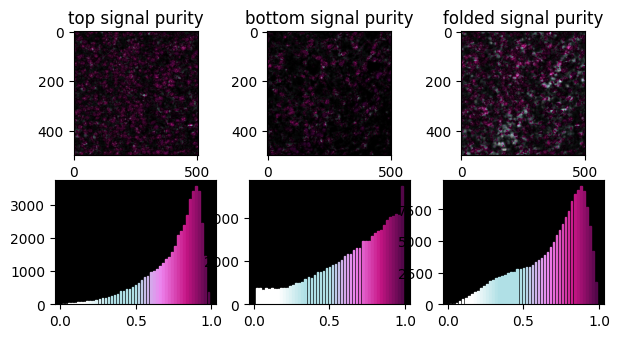

In [12]:
from ovrlpy._plotting import BIH_CMAP as cmap

centimeter = 1 / 2.54


def plot_purity_distribution(coherence, density=None, ax=None):
    if ax is None:
        ax = plt.gca()
    vals, bins = np.histogram(coherence, bins=50, range=(0, 1), density=density)
    colors = cmap(bins[1:-1])
    bars = ax.bar(bins[1:-1], vals[1:], width=0.01)
    for i, bar in enumerate(bars):
        bar.set_color(colors[i])


def plot_image(coherence, signal):
    plt.imshow(
        coherence.T**1,
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        alpha=signal.T / signal.max(),
        interpolation="nearest",
    )


fig = plt.figure(figsize=(18 * centimeter, 9 * centimeter))

ax = plt.subplot(231, facecolor="k")
plt.title("top signal purity")
plot_image(coherence_top, signal_top)
ax = plt.subplot(234, facecolor="k")
plot_purity_distribution(coherence_top[signal_bottom > 1.5], ax=ax)

ax = plt.subplot(232, facecolor="k")
plt.title("bottom signal purity")
plot_image(coherence_bottom, signal_bottom)
ax = plt.subplot(235, facecolor="k")
plot_purity_distribution(coherence_bottom[signal_top > 1.5], ax=ax)

ax = plt.subplot(233, facecolor="k")
plt.title("folded signal purity")
plot_image(coherence_folded, signal_folded)
ax = plt.subplot(236, facecolor="k")
plot_purity_distribution(coherence_folded[signal_folded > 1.5], ax=ax)


plt.savefig(out_dir / "purity_summary.svg", dpi=600)

/tmp/ipykernel_2222167/4287222431.py:10: RuntimeWarning: divide by zero encountered in divide
  hist_quotient = hist_folded / ((hist_top + hist_bot) / 2)
/tmp/ipykernel_2222167/4287222431.py:10: RuntimeWarning: invalid value encountered in divide
  hist_quotient = hist_folded / ((hist_top + hist_bot) / 2)


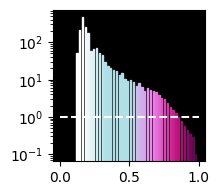

In [13]:
hist_top, _ = np.histogram(
    coherence_top[signal_top > 2.5], bins=np.linspace(0, 1, 50), density=True
)
hist_bot, _ = np.histogram(
    coherence_bottom[signal_bottom > 2.5], bins=np.linspace(0, 1, 50), density=True
)
hist_folded, bins = np.histogram(
    coherence_folded[signal_folded > 2.5], bins=np.linspace(0, 1, 50), density=True
)
hist_quotient = hist_folded / ((hist_top + hist_bot) / 2)

plt.figure(figsize=(5 * centimeter, 5 * centimeter))

ax = plt.subplot(111, facecolor="k")
colors = cmap(bins[1:-1])
bars = ax.bar(bins[1:-1], hist_quotient[1:], width=0.01)
for i, bar in enumerate(bars):
    bar.set_color(colors[i])

ax.set_yscale("log")
plt.hlines(1, 0, 1, linestyles="dashed", color="w")

plt.savefig(out_dir / "purity_quotient.svg", dpi=300)